In [98]:
import uproot
import pandas as pd
import numpy as np
import glob


In [99]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [100]:
import glob

# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_etaetapip_loose_v7_250122_temp"
# cm_elements = ["etahp_13_had_4S_off_v1", "etahp_13_had_4S_v3", "etahp_23_had_4S_off_v1", "etahp_23_had_4S_v1", "etahp_23_had_5Sscan_10657_v1", "etahp_23_had_5Sscan_10706_v1",\
               # "etahp_23_had_5Sscan_10751_v1", "etahp_23_had_5Sscan_10810_v1"]
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250205_Dp_dz"
# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250205_Dp_dz_skimhad"

cm_elements = ["etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1", "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1",\
               "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"]
cut_expression = "Dp_M>0"
tree_name = "etapip_gg_K"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [101]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [102]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,11763.000000,11763.000000,11763.000000,11763.000000,11763.000000
mean,1.677429,0.272480,0.500938,1.603652,0.008586
std,0.149251,0.469664,0.442754,0.773960,1.000006
min,1.500070,-0.914492,-0.884835,0.405252,-1.000000
25%,1.579929,-0.103039,0.212768,0.972684,-1.000000
50%,1.635263,0.380148,0.660348,1.476401,1.000000
75%,1.725492,0.671943,0.867482,2.086254,1.000000
max,2.099948,0.999168,0.968485,4.780845,1.000000


In [103]:
df_proc13 = df_proc13.query('Dp_M> 1.73 & Dp_M<2.1')


In [104]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,2878.000000,2878.000000,2878.000000,2878.000000,2878.000000
mean,1.893053,0.313606,0.567718,1.621976,0.004864
std,0.140266,0.465625,0.440197,0.834427,1.000162
min,1.730052,-0.889119,-0.884835,0.405252,-1.000000
25%,1.773119,-0.040326,0.385734,0.909626,-1.000000
50%,1.813441,0.421933,0.742196,1.502837,1.000000
75%,2.053319,0.698160,0.901439,2.154587,1.000000
max,2.099948,0.999168,0.968485,4.473740,1.000000


In [105]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [106]:
import glob

# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_241213_temp"
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_false"
# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true"

cm_elements = ["15rd_eta_e7_18_4S_v3", "15rd_eta_e20_b26_v1", "15rd_eta_e20_e26_4S_v2", "15rd_eta_e21_5S_scan_v1", "15rd_eta_mori_off_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_gg_K"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    # pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"
    pattern = f"{base_path}/{element}/{tree_name}/train_Dp_dz/all/*.BCS.root"
    # pattern = f"{base_path}/{element}/{tree_name}/train_Dp_dz/skimhad/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [107]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


In [108]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,80787.000000,80787.000000,80787.000000,80787.000000,80787.000000
mean,1.776893,0.269175,0.499738,1.615961,0.001003
std,0.170730,0.476106,0.445058,0.768782,1.000006
min,1.500002,-0.981440,-0.885105,0.400185,-1.000000
25%,1.624265,-0.108993,0.205384,1.009293,-1.000000
50%,1.764876,0.378199,0.663925,1.480734,1.000000
75%,1.950146,0.671784,0.872109,2.085408,1.000000
max,2.099997,0.999851,0.971316,5.049534,1.000000


In [109]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.73 & Dp_M<2.1')


In [110]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,43747.000000,43747.000000,43747.000000,43747.000000,43747.000000
mean,1.914990,0.268533,0.512599,1.604652,-0.002400
std,0.094219,0.475262,0.446376,0.771880,1.000009
min,1.730003,-0.981440,-0.884496,0.400185,-1.000000
25%,1.841199,-0.098104,0.225418,1.004073,-1.000000
50%,1.937061,0.367102,0.681480,1.480091,-1.000000
75%,1.975470,0.669175,0.882032,2.062168,1.000000
max,2.099997,0.999851,0.971316,5.049534,1.000000


In [111]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [112]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity, plot_error_hist


In [113]:
tree_to_compare = tree_name
plt.rcParams['font.family'] = 'DejaVu Sans'


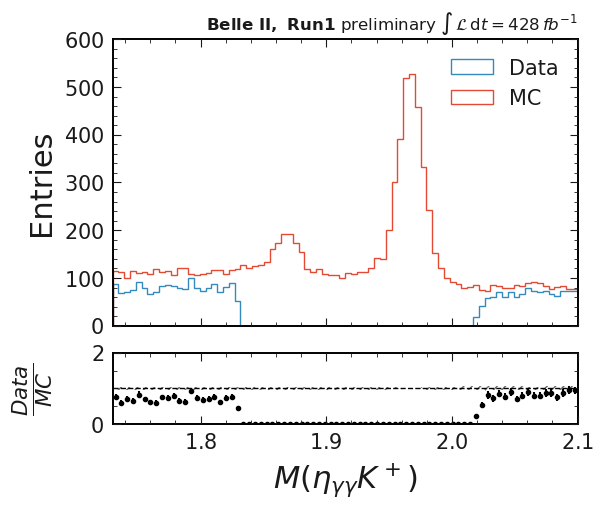

In [114]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{\gamma\gamma} K^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.73,2.1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)

# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")
# ax_main.legend()

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
# fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}_skimhad.png", bbox_inches="tight")
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}_all.png", bbox_inches="tight")